# Notebook 02: O Peso da Leitura – Extensão vs. Qualidade

O objetivo desse notebook é investigar se existe uma correlação entre o número de páginas e a nota média dos livros.

Perguntas de Pesquisa:

    Livros mais longos tem a tendencia a serem mais bem avaliados?

    Existe algum limite onde livros muito extensos começam a receber notas menores?

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

sns.set_theme(style="whitegrid")

df = pd.read_csv('datasets/books.csv')

# Mapa de calor da correlação
Antes de visualizar os dados, calculamos o coeficiente de correlação de Pearson, onde valores próximos de 1 indicam correlação forte positiva, e próximos de -1, correlação forte negativa.


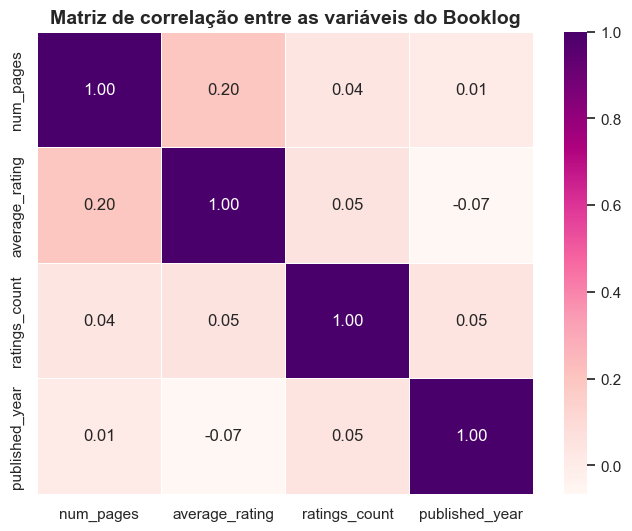

In [7]:
plt.figure(figsize=(8,6))

correlacao = df[['num_pages', 'average_rating', 'ratings_count', 'published_year']].corr()

sns.heatmap(correlacao, annot=True, cmap='RdPu', fmt=".2f", linewidths=0.5)
plt.title('Matriz de correlação entre as variáveis do Booklog', fontsize=14, fontweight='bold')
plt.show()

# Gráfico de dispersão
O gráfico abaixo apresenta a relação direta entre o tamanho do livro e sua nota. A linha de tendência nos dirá visualmente se a nota sobe ou desce conforme o livro cresce.

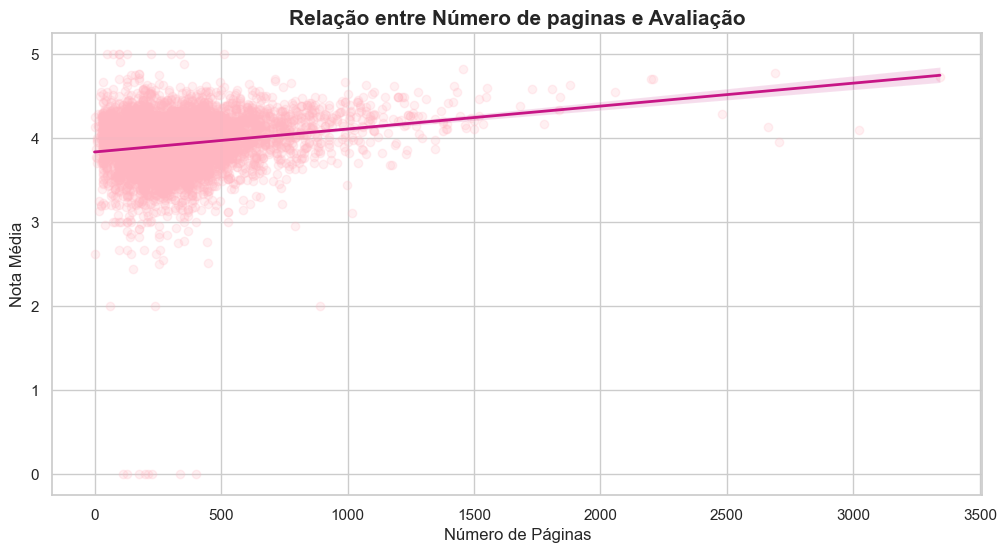

In [5]:
plt.figure(figsize=(12, 6))

sns.regplot(data=df, x='num_pages', y='average_rating', scatter_kws={'alpha': 0.2, 'color': '#FFB6C1'}, line_kws={'color': '#C71585', 'linewidth': 2})

plt.title('Relação entre Número de paginas e Avaliação', fontsize=15, fontweight='bold')
plt.xlabel('Número de Páginas', fontsize=12)
plt.ylabel('Nota Média', fontsize=12)

plt.show()

# Comparativo por faixas de leitura
Agrupamos os livros em quatro perfis: Curtos, Médios, Longos e Extra-longos. Isso permite verificar se existe alguma diferença significativa na média de satisfação entre esses perfis.

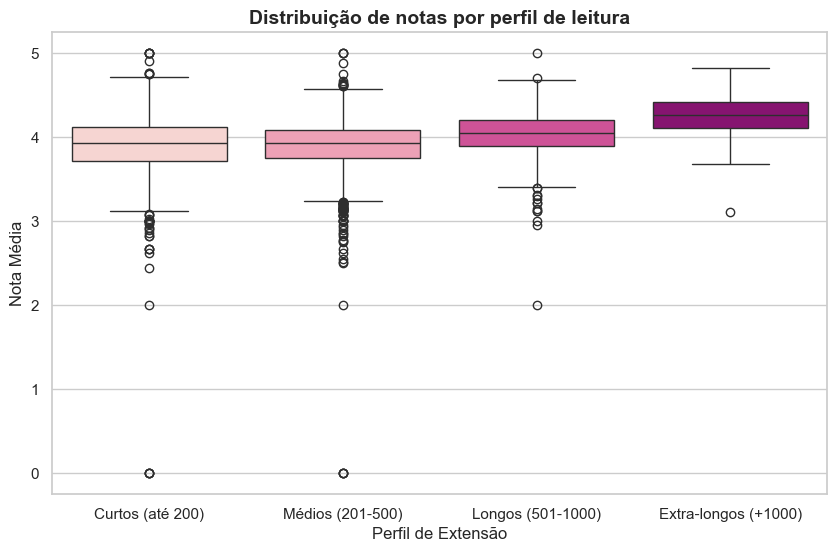

perfil_leitura
Médios (201-500)        3886
Curtos (até 200)        1497
Longos (501-1000)        891
Extra-longos (+1000)     134
Name: count, dtype: int64
Média de nota por perfil:
perfil_leitura
Curtos (até 200)        3.902685
Médios (201-500)        3.907584
Longos (501-1000)       4.038227
Extra-longos (+1000)    4.245896
Name: average_rating, dtype: float64


In [6]:
df['perfil_leitura'] = pd.cut(df['num_pages'], bins=[0, 200, 500, 1000, np.inf], labels=['Curtos (até 200)', 'Médios (201-500)', 'Longos (501-1000)', 'Extra-longos (+1000)']
)

plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='perfil_leitura', y='average_rating', hue='perfil_leitura', palette='RdPu', legend=False)

plt.title('Distribuição de notas por perfil de leitura', fontsize=14, fontweight='bold')
plt.xlabel('Perfil de Extensão')
plt.ylabel('Nota Média')
plt.show()

print(df['perfil_leitura'].value_counts())
print("Média de nota por perfil:")
print(df.groupby('perfil_leitura', observed=False)['average_rating'].mean())

# Conclusão do Notebook 02
Chegamos a conclusão que existe uma tendência positiva, a linha de regressão e o comparativo por perfis de leitura indicam que existe uma correlação levemente positiva entre o tamanho da obra e sua nota. Livros das categorias "Longos" e "Extra-longos" tendem a manter ou superar as médias de satisfação dos livros curtos.

Perfil do público: O fato de livros com mais de 1.000 páginas possuírem boas avaliações sugere que o nosso banco de dados é composto por leitores engajados, que valorizam o aprofundamento do conteúdo.